# 국민은행_토스앱 리뷰 1년치 수집_저장_텍스트분석_mini_project
* 1. google play에서 국민은행 스타뱅킹앱, 토스앱의 사용자 리뷰를 1년치 수집
* 2. 수집한 리뷰를 mysql에 저장
* 3. 수집된 데이터로 긍정/부정 리뷰 비율 분석(막대 그래프 비교)
* 4. 워드클라우드 분석
* 5. LDA 토픽 모델링 분석(최적 k 탐색 포함)
* 6. word2vec 생성 후 T-sne 로 시각화
* 7. 분석 결과를 통해 얻을 수 있는 인사이트(문제점, 개선방안) 보고서 작성

In [3]:
import pandas as pd
from dbio import from_db

In [2]:
toss_df = from_db("bank_app_reviews", "toss_reviews")
kb_df = from_db("bank_app_reviews", "kbbank_reviews")

toss_df["app"] = "토스"
kb_df["app"] = "국민은행"

reviews_df = pd.concat([toss_df, kb_df], ignore_index=True)

reviews_df.to_csv("bank_reviews_all.csv", index=False, encoding="utf-8-sig")

print("통합 CSV 저장 완료")

bank_app_reviews 데이터베이스 확인/생성 완료
bank_app_reviews.toss_reviews 데이터 로드 완료
bank_app_reviews 데이터베이스 확인/생성 완료
bank_app_reviews.kbbank_reviews 데이터 로드 완료
통합 CSV 저장 완료


In [14]:
df = pd.read_csv("bank_reviews_all.csv")

print("원본:", len(df))

df = df.drop_duplicates(subset=["date","rating","review_text","app"])

print("중복 제거 후:", len(df))

원본: 14049
중복 제거 후: 9889


In [23]:
train_df = df
train_df.info()

<class 'pandas.DataFrame'>
Index: 9889 entries, 0 to 9974
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   date         9889 non-null   str  
 1   rating       9889 non-null   int64
 2   review_text  9889 non-null   str  
 3   app          9889 non-null   str  
dtypes: int64(1), str(3)
memory usage: 386.3 KB


In [20]:
train_df = pd.read_csv("./bank_reviews_all.csv")
train_df

,date,rating,review_text,app
0,2026-03-05,1,용량 봐라...내 폰 자원 1기가 육박하게 잡아먹고 있네 ㅎ;;,토스
1,2026-03-05,1,접속이 안됩니다. 특히 3일전부터 아예 안들어가지는 시간대가 너무 길고 잦아요. 다...,토스
2,2026-03-05,1,업데이트하고 나서 왜 이체할 때 비밀번호 치는 창이 투명하게 뜨는 겁니까? 투명하게...,토스
3,2026-03-05,3,폰트가 뭉게져서 나와요,토스
4,2026-03-04,2,진짜 토스좋아하는데 요즘 에러도 자주나고 느려지고 아주 불편해요ㅜㅜㅜ,토스
...,...,...,...,...
14044,2025-03-05,5,구미공단점 직원도움으러잘가입함. 매우만족,국민은행
14045,2025-03-05,1,비대면 뱅킹 가입 인증이 다른 메이저 금융어플 보다 훨씬 복잡함. 주민등록초본 발급...,국민은행
14046,2025-03-05,5,정말 편해요~,국민은행
14047,2025-03-05,5,Ui가 편하네요,국민은행


In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

In [26]:
train_df['rating'].value_counts()

rating
5    3999
1    3726
3     817
4     756
2     591
Name: count, dtype: int64

In [27]:
train_df[train_df['rating'] == 5]

,date,rating,review_text,app
7,2026-03-04,5,간단한 미션으로도 돈을벌수있고 소비복권같은 거랑 토스쇼핑에서 하는 이벤트 너무 유용...,토스
25,2026-03-04,5,다 먹고 나오면 할인해준다고 알람뜨는거 킹받아서 어쩌면좋죠...? 사람 놀리는것도 ...,토스
73,2026-03-03,5,다 좋은데 토스 행운복권 그거 매일 하는데 오늘부터 첫단계만 되고 나머지 단계로 안...,토스
81,2026-03-03,5,고객센터에도 맨앞에 뜨긴 하는데.. 지금 토스 고양이 광고를 봐도 하나도 안 넘어가...,토스
84,2026-03-03,5,요즘 결제 내역에서 지 맘대로 내역 수정하는 경우가 있어요. 3000원인데 취소선 ...,토스
...,...,...,...,...
9969,2025-03-05,5,이해하기쉽게 설명이 참고되어있네요,국민은행
9970,2025-03-05,5,구미공단점 직원도움으러잘가입함. 매우만족,국민은행
9972,2025-03-05,5,정말 편해요~,국민은행
9973,2025-03-05,5,Ui가 편하네요,국민은행


In [28]:
train_df[train_df['rating'] == 4]

,date,rating,review_text,app
16,2026-03-04,4,비밀번호 입력할 때 번호판이 예전엔 검은 화면으로 바뀌면서 흰 색으로 떴는데 지금은...,토스
29,2026-03-04,4,"'자산 변화'에서 총자산으로 설정한 금액으로 ""그래프에서도 동일하게 월변화를 볼수있...",토스
70,2026-03-03,4,광고 보고 포인트 받아져야 되는데 다시 광고가 재생되네요. 오류 수정바랍니다.,토스
80,2026-03-03,4,일주일 방문 미션 버그만 좀 해결해라 제발 존재하지 않는 상품은 왜 있는거야 사실 ...,토스
98,2026-03-03,4,"오늘업뎃이후 20받기, 로또, 만보기복권이 광고후 열리지않네요. 빠른 조치바랍니다....",토스
...,...,...,...,...
9897,2025-03-08,4,반응이 빠름,국민은행
9920,2025-03-07,4,좋아요,국민은행
9931,2025-03-06,4,좋아요,국민은행
9939,2025-03-06,4,빨라서 좋아요,국민은행


In [29]:
train_df[train_df['rating'] == 3]

,date,rating,review_text,app
3,2026-03-05,3,폰트가 뭉게져서 나와요,토스
13,2026-03-04,3,구글 페이 가즈아~,토스
15,2026-03-04,3,금융앱으론 괜찮으나 앱테크로는 너무 많은것을하려다보니 버그현상이 자주일어남으로 조금...,토스
27,2026-03-04,3,아니 당장 급하게 송금할 일이 있어서 돈을 보내야하는데 뭐 인증하니까 안전한 금융거...,토스
28,2026-03-04,3,"도드람농협, 수협 계좌 안불러와지는데 개선 부탁좀요",토스
...,...,...,...,...
9558,2025-03-23,3,간단히 할수 있었네요,국민은행
9697,2025-03-18,3,굿,국민은행
9728,2025-03-16,3,예금 상품 가입하려는데 고객확인제도 (cdd/edd) 를 해야한다고 떠서 하려고 했...,국민은행
9790,2025-03-13,3,타금융인증서 등록했는데.. 로그인하면 튕기고 타금융인증서 해제도 안되고 개발자가 오...,국민은행


In [30]:
train_df[train_df['rating'] == 2]

,date,rating,review_text,app
4,2026-03-04,2,진짜 토스좋아하는데 요즘 에러도 자주나고 느려지고 아주 불편해요ㅜㅜㅜ,토스
8,2026-03-04,2,나만의 지금통 알림 좀 안오게하고 싶습니다. 이전에 만들었다가 해지했는데 왜이리 알...,토스
10,2026-03-04,2,광고 광고 광고 광고 광고,토스
12,2026-03-04,2,뭔 갑자기 900MB인지.. 인원은 또 왜 채용하는지.. 치과의사 앱..,토스
22,2026-03-04,2,갈수록 점점 포인트가 줄어들고 안주는게 많아요 건의 했지만 광고 본다고 포인트를 주...,토스
...,...,...,...,...
9393,2025-03-31,2,감사합니다,국민은행
9398,2025-03-31,2,처음 해 보아서 그런지 상당히 어렵습니다. 그냥 창구로 가서 신세 지는게 좋을 것 ...,국민은행
9659,2025-03-19,2,좋아요,국민은행
9731,2025-03-16,2,"신분증, 얼굴 인식 너무 안 되서 화가 났습니다",국민은행


In [31]:
train_df[train_df['rating'] == 1]

,date,rating,review_text,app
0,2026-03-05,1,용량 봐라...내 폰 자원 1기가 육박하게 잡아먹고 있네 ㅎ;;,토스
1,2026-03-05,1,접속이 안됩니다. 특히 3일전부터 아예 안들어가지는 시간대가 너무 길고 잦아요. 다...,토스
2,2026-03-05,1,업데이트하고 나서 왜 이체할 때 비밀번호 치는 창이 투명하게 뜨는 겁니까? 투명하게...,토스
5,2026-03-04,1,토스로또 광고 봤는데 응모가 안됨,토스
6,2026-03-04,1,처음에는 다른 증권보다 ui가 편해서 섰다. 하지만 시간이 슬슬 지나니 이것저것 덕...,토스
...,...,...,...,...
9849,2025-03-11,1,계좌개설할려고하는데 얼굴 찍는단계에서 계속 튕겨요,국민은행
9855,2025-03-10,1,신분증 촬영 n번째...,국민은행
9889,2025-03-08,1,빗썸때문에 강제로 왔는데 휴면계좌 풀려면 OTP있어야 하고 OTP를 발급하려면 정상...,국민은행
9913,2025-03-07,1,진짜 어플 똑바로 안 만드나ㅋㅋㅋ 얼굴인증 지혼자 0.1초만에 촬영되놓곤 알아볼 수...,국민은행


In [32]:
train_df['label'] = train_df['rating'].apply(lambda x: 1 if x in [4,5] else 0)
train_df

,date,rating,review_text,app,label
0,2026-03-05,1,용량 봐라...내 폰 자원 1기가 육박하게 잡아먹고 있네 ㅎ;;,토스,0
1,2026-03-05,1,접속이 안됩니다. 특히 3일전부터 아예 안들어가지는 시간대가 너무 길고 잦아요. 다...,토스,0
2,2026-03-05,1,업데이트하고 나서 왜 이체할 때 비밀번호 치는 창이 투명하게 뜨는 겁니까? 투명하게...,토스,0
3,2026-03-05,3,폰트가 뭉게져서 나와요,토스,0
4,2026-03-04,2,진짜 토스좋아하는데 요즘 에러도 자주나고 느려지고 아주 불편해요ㅜㅜㅜ,토스,0
...,...,...,...,...,...
9970,2025-03-05,5,구미공단점 직원도움으러잘가입함. 매우만족,국민은행,1
9971,2025-03-05,1,비대면 뱅킹 가입 인증이 다른 메이저 금융어플 보다 훨씬 복잡함. 주민등록초본 발급...,국민은행,0
9972,2025-03-05,5,정말 편해요~,국민은행,1
9973,2025-03-05,5,Ui가 편하네요,국민은행,1


## 🔍긍정/부정 리뷰 분석 (막대그래프)

In [46]:
import re
from konlpy.tag import Mecab
mecab=Mecab()
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split

In [36]:
train_df['app'].unique()

<StringArray>
['토스', '국민은행']
Length: 2, dtype: str

In [47]:
# 텍스트 정리 함수
def text_clean(text):
    temp = re.sub(r"[^가-힣a-zA-Z0-9]", " ", text)
    temp = temp.replace("  ", " ").replace("  ", " ").strip()
    return temp

In [43]:
train_df.columns

Index(['date', 'rating', 'review_text', 'app', 'label'], dtype='str')

In [48]:
train_df['review_text'] = train_df['review_text'].apply(text_clean)
train_df['review_text']

0                           용량 봐라 내 폰 자원 1기가 육박하게 잡아먹고 있네
1       접속이 안됩니다 특히 3일전부터 아예 안들어가지는 시간대가 너무 길고 잦아요 다른 ...
2       업데이트하고 나서 왜 이체할 때 비밀번호 치는 창이 투명하게 뜨는 겁니까 투명하게 ...
3                                            폰트가 뭉게져서 나와요
4                     진짜 토스좋아하는데 요즘 에러도 자주나고 느려지고 아주 불편해요
                              ...                        
9970                                구미공단점 직원도움으러잘가입함 매우만족
9971    비대면 뱅킹 가입 인증이 다른 메이저 금융어플 보다 훨씬 복잡함 주민등록초본 발급받...
9972                                               정말 편해요
9973                                             Ui가 편하네요
9974                    너무쉽게 사용할수있도록해주는 너무좋은 앱 시스템 인것같습니다
Name: review_text, Length: 9889, dtype: str

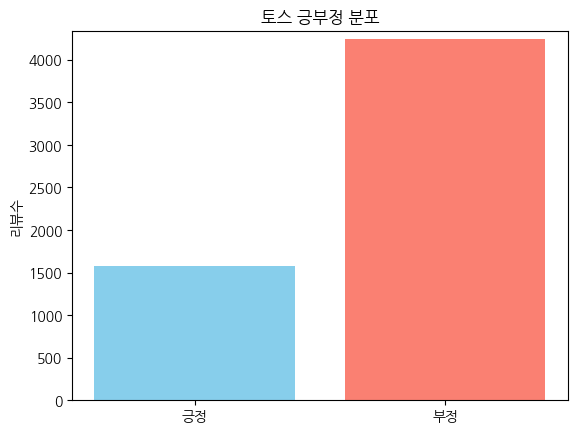

1573 4242


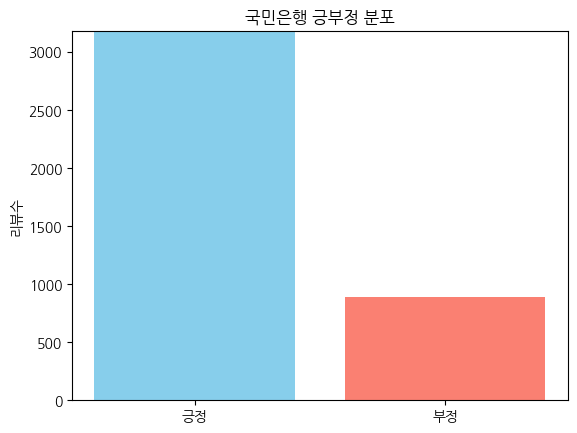

3182 892


{'토스': {'pos':             date  rating                                        review_text  \
  7     2026-03-04       5  간단한 미션으로도 돈을벌수있고 소비복권같은 거랑 토스쇼핑에서 하는 이벤트 너무 유용...   
  16    2026-03-04       4  비밀번호 입력할 때 번호판이 예전엔 검은 화면으로 바뀌면서 흰 색으로 떴는데 지금은...   
  25    2026-03-04       5  다 먹고 나오면 할인해준다고 알람뜨는거 킹받아서 어쩌면좋죠  사람 놀리는것도 아니고...   
  29    2026-03-04       4  자산 변화 에서 총자산으로 설정한 금액으로 그래프에서도 동일하게 월변화를 볼수있게 ...   
  70    2026-03-03       4          광고 보고 포인트 받아져야 되는데 다시 광고가 재생되네요 오류 수정바랍니다   
  ...          ...     ...                                                ...   
  5839  2025-03-05       4                            환전수수료 평생 무료가 아직도 유효 한가요   
  5841  2025-03-05       4  편하게 잘 사용하고 포인트도 많이 적립할수있어서 좋음 단 방문미션은 정답이 맞는데 ...   
  5842  2025-03-05       5                              시간가는줄 모르게 즐거운 여행이였습니다   
  5846  2025-03-05       5  홈화면 커스텀 해서 보고싶은 계좌 세팅 다해놨는데 뭔 자주보는 계좌니 뭐니 맘대로 ...   
  5847  2025-03-05       5                                가족들 한테 추천받아 사용중 쪼와요   
  
       app  

In [52]:
pos_neg_dict = {}
for bank in train_df['app'].unique():
    pos = train_df[(train_df['app'] == bank) & (train_df['label'] == 1)]
    neg = train_df[(train_df['app'] == bank) & (train_df['label'] == 0)]
    
    # bank 기준으로 pos/neg 저장
    pos_neg_dict[bank] = {
        "pos" : pos,
        "neg" : neg
    }
    
    # 시각화
    plt.bar(['긍정', '부정'], [pos.shape[0], neg.shape[0]], color=['skyblue', 'salmon'])
    plt.title(f"{bank} 긍부정 분포")
    plt.ylabel("리뷰수")
    plt.ylim(0, max(pos.shape[0], neg.shape[0] +100))
    plt.show()
    print(pos.shape[0], neg.shape[0])
pos_neg_dict

## 🔍은행별 리뷰 워드클라우드 만들기

In [55]:
# !pip install wordcloud

In [56]:
from wordcloud import WordCloud

In [81]:
stopwords = set(['은행', '어플', '뱅킹', '앱', '토스', '국민은행'])

In [71]:
import os

============================== 토스 pos ==============================
상위 10개 단어 빈도
계좌: 185
업데이트: 164
편리: 145
기능: 142
화면: 136
증권: 125
불편: 113
주식: 107
광고: 101
감사: 84


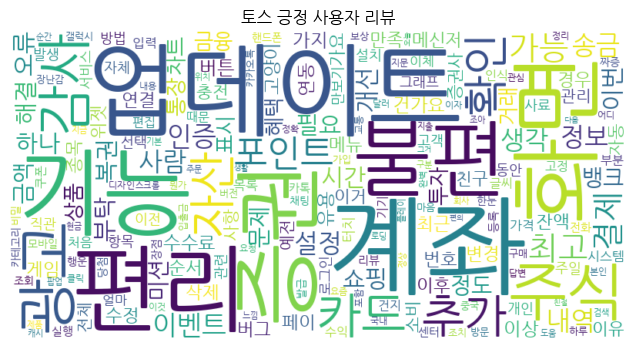

============================== 토스 neg ==============================
상위 10개 단어 빈도
광고: 1333
업데이트: 940
계좌: 839
불편: 571
화면: 513
증권: 415
고양이: 277
시간: 271
포인트: 264
결제: 264


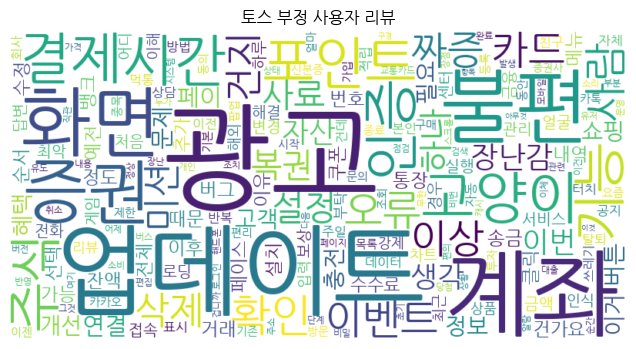

============================== 국민은행 pos ==============================
상위 10개 단어 빈도
편리: 578
만족: 196
감사: 189
가입: 102
친절: 92
처리: 71
최고: 66
설명: 61
계좌: 44
스타: 42


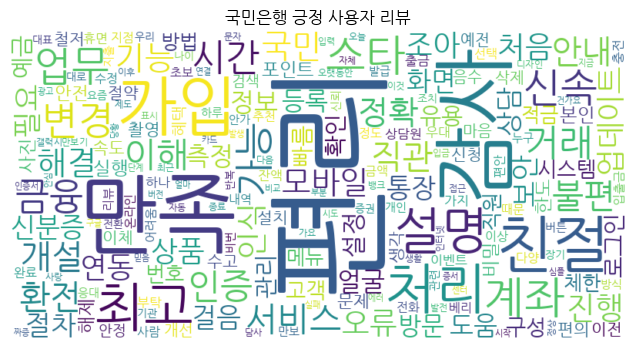

============================== 국민은행 neg ==============================
상위 10개 단어 빈도
인식: 152
걸음: 131
인증: 130
업데이트: 124
신분증: 117
계좌: 111
오류: 90
얼굴: 87
확인: 80
불편: 78


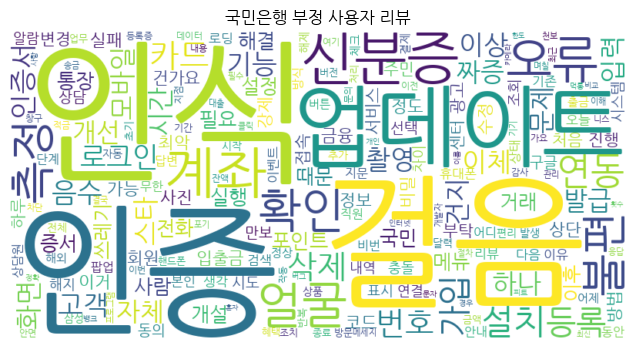

In [119]:
for bank, pos_neg in pos_neg_dict.items():
    for label, df in pos_neg.items():
        print("=" * 30, bank, label, "=" * 30)
        full_text = " ".join(df['review_text'].tolist())
#         print(full_text[:100])
        
        # 은행 이름을 불용어에 추가
        bank_name = df['app'].iloc[0]
        stopwords.add(bank_name)
        
        # 명사 추출
        nouns = mecab.nouns(full_text)
        filtered = [word for word in nouns if len(word) > 1 and word not in stopwords]
        
        # 단어의 빈도 계산
        word_freq = Counter(filtered)
        top10 = word_freq.most_common(10)

        print("상위 10개 단어 빈도")
        for word, count in top10:
            print(f"{word}: {count}")
        
        wc = WordCloud(
                font_path="NanumGothic.ttf",
                background_color='white',
                width = 800,
                height=400
                ).generate_from_frequencies(word_freq)
        
        # 긍/부정 레이블 텍스트 만들기
        sentiment_txt = "긍정" if label == 'pos' else "부정"
        
        plt.figure(figsize=(8,4))
        plt.imshow(wc, interpolation="bilinear")
        plt.axis('off')
        plt.title(f"{bank_name} {sentiment_txt} 사용자 리뷰")
        
        if not os.path.exists("img"):
            os.mkdir("img")
        save_name = f"./img/{bank_name} {sentiment_txt} 사용자 리뷰.png"
        plt.savefig(save_name, dpi=300, bbox_inches='tight')
        plt.show()

## 🔍LDA 토픽 모델링 분석(최적 k 탐색 포함)

In [76]:
# !pip install gensim

In [77]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from gensim import corpora
from gensim.models.coherencemodel import CoherenceModel
from konlpy.tag import Mecab
mecab = Mecab()

In [98]:
stopwords = set(['은행','어플','앱','뱅킹','토스','국민은행','kb','사용','이용','진짜','너무','정말','그냥','이게','바로'
])

In [99]:
def mecab_tokenizer(text):
    return [w for w in mecab.nouns(str(text)) if len(w) > 1 and w not in stopwords]

### 최적 토픽 수 탐색

In [100]:
def find_optimal_topics(texts, start=2, end=20, min_df=5, max_df=0.9, topn=10, random_state=42):
    # list로 변경된 series를 토큰화하고 길이 2이상인 것만 남김
    pairs = [(t, mecab_tokenizer(t)) for t in texts]
    pairs = [(t, tok) for (t, tok) in pairs if len(tok) >= 2]
#     print(pairs)
    filtered_texts = [t for (t, tok) in pairs]
    tokenized_texts = [tok for (t, tok) in pairs]
    
#     print(tokenized_texts)
    if len(tokenized_texts) < 5:
        return start, filtered_texts, tokenized_texts
    
    # 토픽이 너무 많은 경우 숫자 제한
    max_k = min(end, max(start, len(tokenized_texts) // 2))
    if max_k < start:
        return start, filtered_texts, tokenized_texts
    
    # coherence 계산용 dictionary 만들기
    dictionary = corpora.Dictionary(tokenized_texts)

#     print("단어 개수", len(dictionary))
#     print("샘플 단어", list(dictionary.token2id.keys())[:100])
    
    # 문자를 벡터화
    vectorizer = CountVectorizer(
        tokenizer=mecab_tokenizer,
        preprocessor=None,
        token_pattern=None,
        lowercase=False,
        min_df=min_df,
        max_df=max_df)
    
    try:
        doc_term_matrix = vectorizer.fit_transform(filtered_texts)
    except Exception as e:
        print(e, "\n벡터화 오류, 기본 토픽수 반환")
        return start, filtered_texts, tokenized_texts
    
    if doc_term_matrix.shape[1] == 0:
        print("min_df, max_df로 단어 전부 제거, 기본 토픽수 반환")
        return start, filtered_texts, tokenized_texts
    
    feature_names = vectorizer.get_feature_names_out()
    
    best_score = -1
    best_n = start
    
    for n_topics in range(start, max_k + 1):
        lda_model = LatentDirichletAllocation(
                n_components=n_topics,
                random_state=random_state,
                learning_method='batch')
        lda_model.fit(doc_term_matrix)
        
        topics = [
            [feature_names[i] for i in topic.argsort()[:-topn-1:-1]]
            for topic in lda_model.components_
        ]
        
        cm = CoherenceModel(
            topics=topics,
            texts=tokenized_texts,
            dictionary=dictionary,
            coherence="c_v"
            )
        score = cm.get_coherence()
        
        print(f"토픽수: {n_topics}, Coherence Score: {score:.4f}")
        
        if score > best_score:
            best_score = score
            best_n = n_topics
    
    print(f"최적 토픽수: {best_n} (score: {best_score:.4f})")
    return best_n, filtered_texts, tokenized_texts


### 토픽 모델링

In [101]:
print("--- 토픽 모델링 시작 ---")
VEC_MIN_DF = 10
VEC_MAX_DF = 0.9

topn_words_print = 10
topn_coherence = 10

start_k = 2
end_k = 20

topic_words_map = {}

for bank_eng, pn in pos_neg_dict.items():
    for senti in pn:
        series = pn[senti]['review_text']
        texts = series.tolist()
        
        # 최적 토픽수 + 필터된 문서 + 토큰화된 리스트 함께 받기
        best_k, filtered_texts, tokenized_texts = find_optimal_topics(
            texts=texts,
            start=start_k,
            end=end_k,
            min_df=VEC_MIN_DF,
            max_df=VEC_MAX_DF,
            topn=topn_coherence,
            random_state=42
            )
        
        # 
        if len(tokenized_texts) < 20:
            print(f"{bank_eng} ({senti}) 유효 토큰 문서 부족 ({len(tokenized_texts)}개) - 스킵")
            continue
        
        # 카운터벡터라이저로 문자 => 숫자          
        vectorizer = CountVectorizer(
            tokenizer=mecab_tokenizer,
            preprocessor=None,
            token_pattern=None,
            lowercase=False,
            min_df=VEC_MIN_DF,
            max_df=VEC_MAX_DF)
                  
        try:
            review_vec = vectorizer.fit_transform(filtered_texts)
        except Exception as e:
            print(e, f"\n{bank_eng} ({senti}) 벡터화 오류, 기본 토픽수 반환")
            continue

        if review_vec.shape[1] == 0:
            print(f"{senti} min_df 조건 만족 단어 없음 - 스킵")
            continue
        
        #최적 k로 lda 재학습
        lda = LatentDirichletAllocation(
                n_components=best_k,
                random_state=42,
                learning_method='batch')
        lda.fit(review_vec)
                  
        words = vectorizer.get_feature_names_out()
                  
        # 토픽 단어 출력 + 저장
        all_topic_words = set()
        
        print(f"\n[{bank_eng}] {senti} 토픽 {best_k}개 - 상위 단어")
        print("=" * 60)
        for i, topic in enumerate(lda.components_):
            top_idx = topic.argsort()[-topn_words_print:][::-1]
            top_words = [words[idx] for idx in top_idx]
            print(f"토픽 #{i}: {top_words}\n")
            all_topic_words.update(top_words)
            
        topic_words_map[(bank_eng, senti)] = all_topic_words
    print("--- 토픽 모델링 종료 ---")

--- 토픽 모델링 시작 ---
토픽수: 2, Coherence Score: 0.4602
토픽수: 3, Coherence Score: 0.4268
토픽수: 4, Coherence Score: 0.4093
토픽수: 5, Coherence Score: 0.4084
토픽수: 6, Coherence Score: 0.4396
토픽수: 7, Coherence Score: 0.4079
토픽수: 8, Coherence Score: 0.3962
토픽수: 9, Coherence Score: 0.3557
토픽수: 10, Coherence Score: 0.3938
토픽수: 11, Coherence Score: 0.4014
토픽수: 12, Coherence Score: 0.3880
토픽수: 13, Coherence Score: 0.3621
토픽수: 14, Coherence Score: 0.3511
토픽수: 15, Coherence Score: 0.3483
토픽수: 16, Coherence Score: 0.3857
토픽수: 17, Coherence Score: 0.4114
토픽수: 18, Coherence Score: 0.3787
토픽수: 19, Coherence Score: 0.3848
토픽수: 20, Coherence Score: 0.3764
최적 토픽수: 2 (score: 0.4602)

[토스] pos 토픽 2개 - 상위 단어
토픽 #0: ['광고', '포인트', '결제', '이벤트', '감사', '쇼핑', '최고', '해결', '복권', '미션']

토픽 #1: ['계좌', '업데이트', '기능', '화면', '증권', '불편', '주식', '카드', '자산', '추가']

토픽수: 2, Coherence Score: 0.2922
토픽수: 3, Coherence Score: 0.3907
토픽수: 4, Coherence Score: 0.4147
토픽수: 5, Coherence Score: 0.4412
토픽수: 6, Coherence Score: 0.4697
토픽수: 7, Coh

## 🔍word2vec 생성 후 T-sne 로 시각화

In [104]:
# !pip install tensorflow

In [105]:
# tokenized = [mecab_tokenizer(t) for t in texts if len(toks) >= 2]
def tokenize_docs(texts):
    tokenized = []
    for t in texts:
        toks = mecab_tokenizer(t)
        if len(toks) >= 2:
            tokenized.append(toks)
    return tokenized

### word2vec 학습

In [106]:
from gensim.models import Word2Vec

In [107]:
w2v_model = None

all_reviews = train_df['review_text'].tolist()
all_tokenized = tokenize_docs(all_reviews)

if len(all_tokenized) >= 5:
    w2v_model = Word2Vec(
        sentences=all_tokenized,
        vector_size=100,
        window=5,
        min_count=2,
        workers=-1,
        sg=1,
        seed=42
        )
    print(f"Word2vec 학습완료 | 전체 리뷰 {len(all_reviews)} | 유효 토큰 문서: {len(all_tokenized)}")
else:
    print("word2vec 학습용 유효 토큰 문서가 너무 적어 학습 건너뜀")
    

Word2vec 학습완료 | 전체 리뷰 9889 | 유효 토큰 문서: 6471


In [108]:
topic_words_map

{('토스', 'pos'): {'감사',
  '결제',
  '계좌',
  '광고',
  '기능',
  '미션',
  '복권',
  '불편',
  '쇼핑',
  '업데이트',
  '이벤트',
  '자산',
  '주식',
  '증권',
  '최고',
  '추가',
  '카드',
  '포인트',
  '해결',
  '화면'},
 ('토스', 'neg'): {'가입',
  '개선',
  '거래',
  '건지',
  '겁니까',
  '게임',
  '결제',
  '계좌',
  '고객',
  '고양이',
  '공지',
  '관리',
  '광고',
  '교통카드',
  '구매',
  '기능',
  '내역',
  '답변',
  '데이터',
  '만보기',
  '메뉴',
  '모바일',
  '문제',
  '미션',
  '방문',
  '뱅크',
  '버그',
  '버스',
  '버전',
  '버튼',
  '번호',
  '보상',
  '복권',
  '본인',
  '불편',
  '비번',
  '사람',
  '사료',
  '삭제',
  '상담',
  '상품',
  '선택',
  '설정',
  '설치',
  '센터',
  '송금',
  '쇼핑',
  '수정',
  '순서',
  '시간',
  '신분증',
  '실행',
  '쓰레기',
  '어디',
  '얼굴',
  '업데이트',
  '연결',
  '예전',
  '오류',
  '이번',
  '이벤트',
  '이상',
  '이후',
  '인식',
  '인증',
  '입력',
  '자동',
  '자산',
  '잔액',
  '장난',
  '장난감',
  '전체',
  '전화',
  '접속',
  '정보',
  '조회',
  '종목',
  '주식',
  '주일',
  '증권',
  '짜증',
  '충전',
  '친구',
  '카드',
  '카카오',
  '쿠폰',
  '탈퇴',
  '터치',
  '통장',
  '페이',
  '페이스',
  '페이지',
  '포인트',
  '하나',
  '해결',
  '해외',
  '혜택',
  '화면',
  '확

### T-SNE 시각화

In [109]:
from sklearn.manifold import TSNE


[토스](pos) 토픽단어 20개 | w2v포함 20개
T-SNE perplexity = 6

[토스](neg) 토픽단어 100개 | w2v포함 100개
T-SNE perplexity = 15

[국민은행](pos) 토픽단어 29개 | w2v포함 29개
T-SNE perplexity = 9

[국민은행](neg) 토픽단어 44개 | w2v포함 44개
T-SNE perplexity = 14


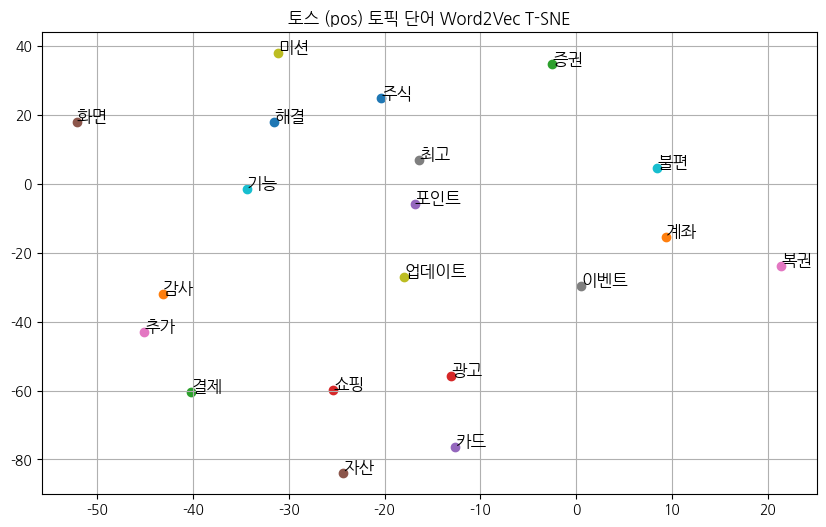

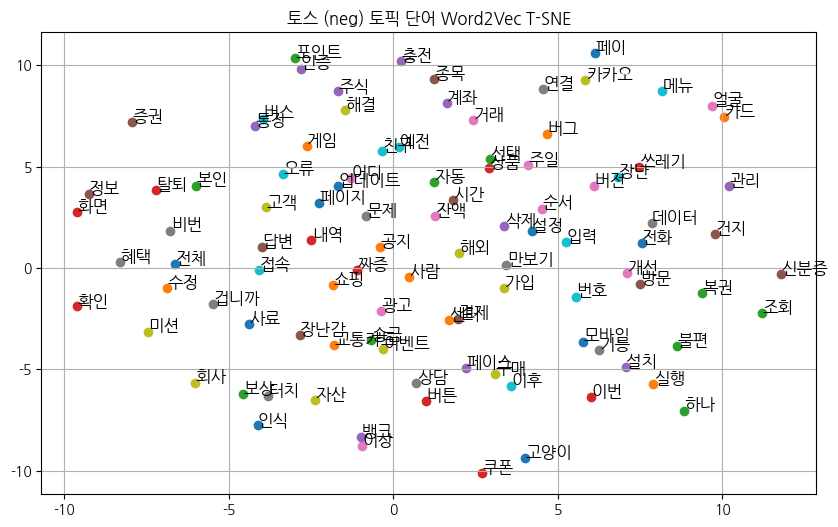

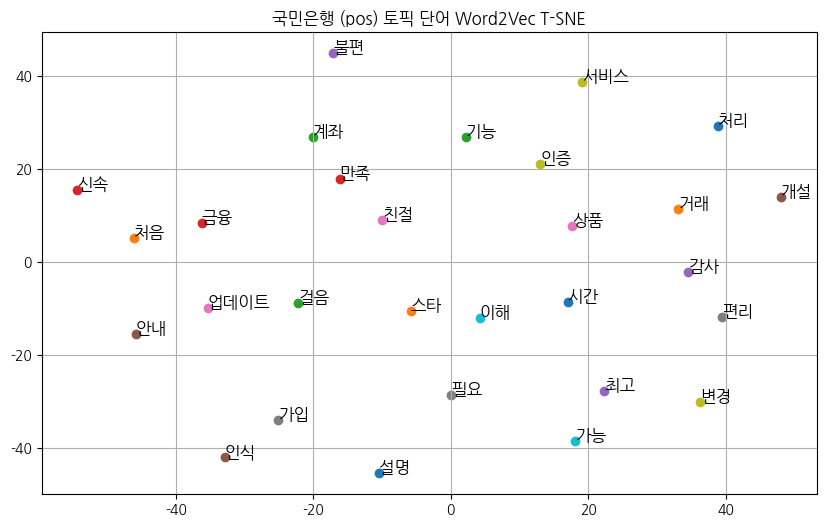

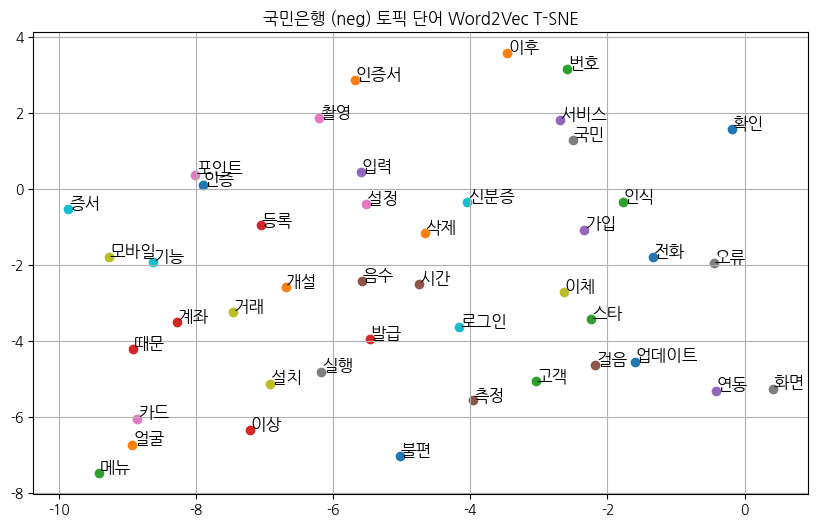

In [110]:
for (bank_eng, senti), all_topic_words in topic_words_map.items():
    valid_words = [w for w in all_topic_words if w in w2v_model.wv]
    print(f"\n[{bank_eng}]({senti}) 토픽단어 {len(all_topic_words)}개 | w2v포함 {len(valid_words)}개")
    
    vectors = np.array([w2v_model.wv[w] for w in valid_words])
    
    #perplexity 자동조절
    tsne_perplexity = min(15, max(5, (len(valid_words) -1) // 3))
    tsne_perplexity = min(tsne_perplexity, len(valid_words) -1)
    if tsne_perplexity < 2:
        tsne_perplexity = 2
    print(f"T-SNE perplexity = {tsne_perplexity}")
    
    tsne = TSNE(
            n_components=2,
            random_state=0,
            perplexity=tsne_perplexity,
            init='pca',
            learning_rate="auto"
            )
    reduced_vecs = tsne.fit_transform(vectors)
    
    plt.figure(figsize=(10,6))
    for i, word in enumerate(valid_words):
        x, y = reduced_vecs[i]
        plt.scatter(x, y)
        plt.text(x + 0.01, y+0.01, word, fontsize=12)
    plt.title(f"{bank_eng} ({senti}) 토픽 단어 Word2Vec T-SNE")
    plt.grid(True)